A note on POD values: as will be clearly visible in the plot below, the POD values have an interesting distribution very different from LD50 values, in that they contain exceptionally large and very isolated values on occasion. This may make them hard for GenRA to predict. Results should be checked for bias: the extremely skewed distribution of POD values may lead to poor measurements of r2, so rmse or a modified custom r2 should likely be used to measure error instead. These tests may also serve as an interesting test case for use of a universal max distance vs. a chemical test-specific scaling factor, as worked on in my changes to GenRA.

In [28]:
import pandas as pd
data = pd.read_csv("../src/data/toxval_pre-grid-search_and_TEST.csv").set_index("dsstox_sid")

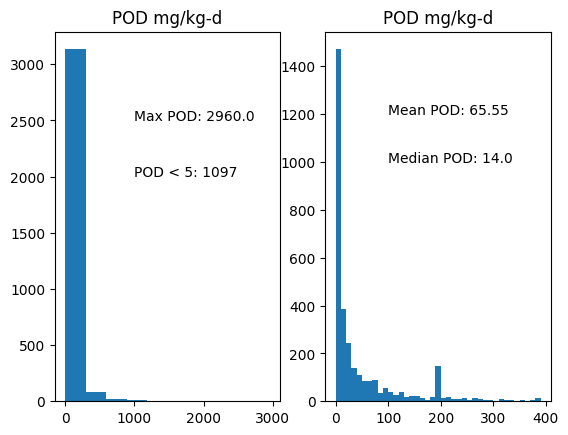

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1,2)
axs[0].hist(data['POD'])
axs[0].set_title("POD mg/kg-d")
axs[1].hist(data['POD'], bins = np.arange(0,400,10))
axs[1].set_title("POD mg/kg-d")
axs[1].annotate(f"Mean POD: {round(np.mean(data['POD']),2)}", xy = (100,1200))
axs[1].annotate(f"Median POD: {round(np.median(data['POD']),2)}", xy = (100,1000))
axs[0].annotate(f"Max POD: {round(max(data['POD']),4)}", xy = (1000,2500))
axs[0].annotate(f"POD < 5: {round(len(data.loc[data['POD']< 5, :]),4)}", xy = (1000,2000))

plt.show()

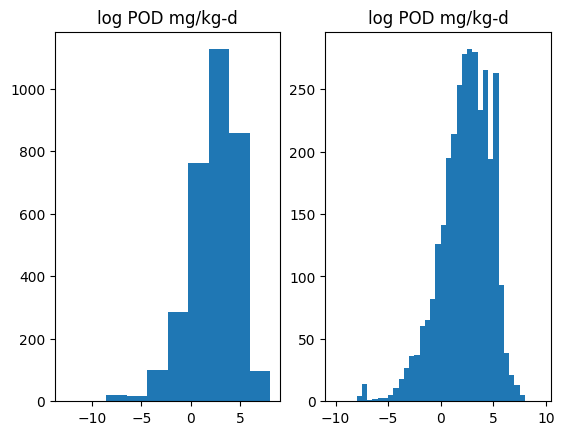

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1,2)
axs[0].hist(np.log(data['POD']))
axs[0].set_title("log POD mg/kg-d")
axs[1].hist(np.log(data['POD']), bins = np.arange(-10,10,0.5))
axs[1].set_title("log POD mg/kg-d")
axs[1].annotate(f"Mean POD: {round(np.mean(data['POD']),2)}", xy = (100,1200))
axs[1].annotate(f"Median POD: {round(np.median(data['POD']),2)}", xy = (100,1000))
axs[0].annotate(f"Max POD: {round(max(data['POD']),4)}", xy = (1000,2500))
axs[0].annotate(f"POD < 5: {round(len(data.loc[data['POD']< 5, :]),4)}", xy = (1000,2000))

plt.show()

In [36]:
#Create a version with this log-transformed version of the POD values
log_data = data.copy()
log_data = log_data.rename(columns = {'POD':'log_POD'})
log_data['log_POD'] = np.log(data['POD'])

In [38]:
#Save the new version of the data
log_data.to_csv("../src/data/toxval_log_pre-grid-search_and_TEST.csv")

In [40]:
#Send this version out to the VM
print(f"scp src/data/toxval_log_pre-grid-search_and_TEST.csv aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/data")

scp src/data/toxval_log_pre-grid-search_and_TEST.csv aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/data


# Grid Search Results

In [46]:
toxval_ten_list = [5497, 8943, 9901, 1534, 1335, 741, 5160, 6446, 4355, 3875]
main_endpoint = 'toxval'
#Import Grid Search Results (remember this must be done in Bash)
print("scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/toxval/grid_search_{5497,8943,9901,1534,1335,741,5160,6446,4355,3875}.csv references/full_print_results/toxval")

scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/toxval/grid_search_{5497,8943,9901,1534,1335,741,5160,6446,4355,3875}.csv references/full_print_results/toxval


## Raw POD values

In [19]:
#Load the data and remove machine performance and unecessary columns
results_master = []
for state in toxval_ten_list:
    results = pd.read_csv(f"../references/full_print_results/toxval/grid_search_{state}.csv")
    results = results.drop(columns={"Unnamed: 0", "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time", "params"})
    
    #Often, the test [0,0,0,100] will result in null results, so drop that test (causes discussed in OneNote)
    results = results.drop(0)
    results["state"] = [state for _ in range(0,len(results))]
    results_master.append(results)
results= pd.concat(results_master)

In [20]:
#Sort and ensure that indexing is correct for data type adjustments
results = results.sort_values(['state','mean_test_neg_root_mean_squared_error'], ascending=False)
results = results.reset_index()
results = results.drop(columns={"index", "split3_test_r2","split4_test_r2", "split3_test_neg_root_mean_squared_error","split4_test_neg_root_mean_squared_error" })
results.head(10)

,param_hybrid_weights,param_n_neighbors,split0_test_r2,split1_test_r2,split2_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,state
0,"[10, 35, 5, 50]",8,0.129682,0.114495,0.231331,0.200043,0.072992,1,-115.620194,-117.787644,-177.304225,-145.049790,33.915613,1,9901
1,"[10, 30, 5, 55]",8,0.109032,0.125110,0.231076,0.199127,0.077780,3,-116.983780,-117.079520,-177.333639,-145.106465,34.021106,2,9901
2,"[15, 65, 10, 10]",8,0.095723,0.050048,0.239559,0.190040,0.103715,32,-117.854290,-121.998646,-176.352691,-145.301390,32.294011,3,9901
3,"[15, 25, 10, 50]",8,0.134757,0.135013,0.214450,0.199842,0.067848,2,-115.282589,-116.415008,-179.240596,-145.362695,35.121539,4,9901
4,"[15, 70, 10, 5]",8,0.109198,0.030674,0.237468,0.189177,0.108764,47,-116.972926,-123.236437,-176.594958,-145.387454,32.606910,5,9901
5,"[10, 70, 10, 10]",8,0.139659,0.020979,0.230979,0.190059,0.105374,31,-114.955538,-123.851232,-177.344825,-145.454471,33.039832,6,9901
6,"[15, 55, 10, 20]",8,0.120224,0.041480,0.242047,0.190196,0.100985,29,-116.246762,-122.547648,-176.063985,-145.456800,32.990467,7,9901
7,"[15, 35, 10, 40]",8,0.139249,0.120502,0.227454,0.197371,0.066017,4,-114.982951,-117.387474,-177.750799,-145.472501,34.573933,8,9901
8,"[5, 55, 10, 30]",8,0.168169,0.060604,0.223909,0.193563,0.077920,12,-113.034798,-121.318922,-178.158117,-145.502710,33.407700,9,9901
9,"[10, 30, 10, 50]",8,0.085642,0.131305,0.228833,0.194534,0.084312,8,-118.509434,-116.664289,-177.592099,-145.512022,34.350423,10,9901


In [21]:
#Process the new DataFrame, reassigning types as needed
new_weights = []
for i in results["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(last)])
results["param_hybrid_weights"] = new_weights


#Note that weights imported as a string. This code will amend that for us and replace the string column
#with individual numberical weight columns that can be used in graphing and analysis
morgan_weight = [results["param_hybrid_weights"][i][1] for i in range(0,len(results["param_hybrid_weights"]))]
toxprint_weight = [results["param_hybrid_weights"][i][0] for i in range(0,len(results["param_hybrid_weights"]))]
torsion_weight = [results["param_hybrid_weights"][i][2] for i in range(0,len(results["param_hybrid_weights"]))]
aims_weight = [results["param_hybrid_weights"][i][3] for i in range(0,len(results["param_hybrid_weights"]))]

results["morgan"] = [morgan_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
results["toxprint"] = [toxprint_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
results["torsion"] = [torsion_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
results["aims"] = [aims_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]

In [27]:
#View optimal results for each state, based on an average of the tests with the top 10 performances as measured
#by rmse
max_results = results.loc[results['rank_test_neg_root_mean_squared_error']<=10]
view_max_results = max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .groupby('state').mean()[['mean_test_r2', 'mean_test_neg_root_mean_squared_error', 'morgan', 'toxprint', 'torsion', 'aims']]
view_max_results

,mean_test_r2,mean_test_neg_root_mean_squared_error,morgan,toxprint,torsion,aims
state,,,,,,
741,0.196926,-132.996841,0.150,0.415,0.415,0.020
1335,0.087539,-126.595229,0.075,0.505,0.365,0.055
1534,0.232281,-136.891280,0.385,0.405,0.175,0.035
3875,0.273039,-136.578858,0.440,0.190,0.350,0.020
4355,0.174786,-146.074466,0.665,0.130,0.005,0.200
5160,0.213773,-146.157659,0.180,0.080,0.005,0.735
5497,0.179848,-143.054881,0.270,0.515,0.155,0.060
6446,0.121312,-140.456126,0.235,0.290,0.470,0.005
8943,0.143732,-144.188380,0.175,0.705,0.010,0.110


In [25]:
#Remove non-numerical columns, and take a mean of the previous DataFrame to view our prediction for best
#hybrid weight
best_combo = max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .mean()[["morgan", "toxprint", "torsion", "aims", "mean_test_neg_root_mean_squared_error", "mean_test_r2"]]
best_combo_weights = [best_combo['toxprint'], best_combo['morgan'], best_combo['torsion'], best_combo['aims']]
best_combo

morgan                                     0.304500
toxprint                                   0.335500
torsion                                    0.204000
aims                                       0.156000
mean_test_neg_root_mean_squared_error   -139.835435
mean_test_r2                               0.181763
dtype: float64

## Log-transformed POD values

In [51]:
#Load the data and remove machine performance and unecessary columns
results_master = []
for state in toxval_ten_list:
    results = pd.read_csv(f"../references/full_print_results/toxval/grid_search_log_{state}.csv")
    results = results.drop(columns={"Unnamed: 0", "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time", "params"})
    
    #Often, the test [0,0,0,100] will result in null results, so drop that test (causes discussed in OneNote)
    results = results.drop(0)
    results["state"] = [state for _ in range(0,len(results))]
    results_master.append(results)
results= pd.concat(results_master)

In [53]:
#Sort and ensure that indexing is correct for data type adjustments
results = results.sort_values(['state','mean_test_neg_root_mean_squared_error'], ascending=False)
results = results.reset_index()
results = results.drop(columns={"index", "split3_test_r2","split4_test_r2", "split3_test_neg_root_mean_squared_error","split4_test_neg_root_mean_squared_error" })
results.head(10)

,param_hybrid_weights,param_n_neighbors,split0_test_r2,split1_test_r2,split2_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,state
0,"[40, 30, 30, 0, 0]",8,0.422695,0.388457,0.384445,0.396468,0.017707,1,-1.944906,-1.905708,-1.798229,-1.877802,0.056695,1,9901
1,"[30, 40, 30, 0, 0]",8,0.420267,0.399829,0.382185,0.392824,0.017228,2,-1.948991,-1.887906,-1.801526,-1.883563,0.059321,2,9901
2,"[40, 20, 40, 0, 0]",8,0.414536,0.398774,0.372657,0.391347,0.019196,3,-1.958601,-1.889565,-1.815364,-1.885577,0.053146,3,9901
3,"[30, 30, 30, 10, 0]",8,0.411222,0.393735,0.389455,0.391131,0.015396,4,-1.964136,-1.897466,-1.790896,-1.886413,0.063691,4,9901
4,"[30, 40, 20, 10, 0]",8,0.413113,0.391397,0.392514,0.391003,0.016898,5,-1.960980,-1.901122,-1.786404,-1.886561,0.063915,5,9901
5,"[40, 10, 50, 0, 0]",8,0.409749,0.403195,0.371384,0.390608,0.020529,6,-1.966592,-1.882605,-1.817206,-1.886660,0.053319,6,9901
6,"[30, 30, 40, 0, 0]",8,0.419767,0.403769,0.372436,0.390522,0.019262,7,-1.949832,-1.881699,-1.815685,-1.886966,0.057249,7,9901
7,"[50, 20, 30, 0, 0]",8,0.414022,0.384917,0.381534,0.390419,0.018093,8,-1.959460,-1.911216,-1.802475,-1.887197,0.057530,8,9901
8,"[30, 50, 20, 0, 0]",8,0.412742,0.377290,0.382319,0.390405,0.015813,9,-1.961600,-1.923028,-1.801331,-1.887472,0.062383,9,9901
9,"[30, 40, 20, 0, 10]",8,0.404970,0.382052,0.378602,0.390379,0.011951,10,-1.974536,-1.915661,-1.806743,-1.887768,0.065984,10,9901


In [55]:
#Process the new DataFrame, reassigning types as needed
new_weights = []
for i in results["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(number_list[3]), int(last)])
results["param_hybrid_weights"] = new_weights


#Note that weights imported as a string. This code will amend that for us and replace the string column
#with individual numberical weight columns that can be used in graphing and analysis
morgan_weight = [results["param_hybrid_weights"][i][1] for i in range(0,len(results["param_hybrid_weights"]))]
toxprint_weight = [results["param_hybrid_weights"][i][0] for i in range(0,len(results["param_hybrid_weights"]))]
torsion_weight = [results["param_hybrid_weights"][i][2] for i in range(0,len(results["param_hybrid_weights"]))]
aims_weight = [results["param_hybrid_weights"][i][3] for i in range(0,len(results["param_hybrid_weights"]))]
test_weight = [results["param_hybrid_weights"][i][4] for i in range(0,len(results["param_hybrid_weights"]))]

results["morgan"] = [morgan_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
results["toxprint"] = [toxprint_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
results["torsion"] = [torsion_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
results["aims"] = [aims_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]
results["test"] = [test_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(test_weight))]

In [65]:
#View optimal results for each state, based on an average of the tests with the top 10 performances as measured
#by rmse
max_results = results.loc[results['rank_test_neg_root_mean_squared_error']<=10]
view_max_results = max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .groupby('state').mean()[['mean_test_r2', 'mean_test_neg_root_mean_squared_error', 'morgan', 'toxprint', 'torsion', 'aims', 'test']]
view_max_results

,mean_test_r2,mean_test_neg_root_mean_squared_error,morgan,toxprint,torsion,aims,test
state,,,,,,,
741,0.387165,-1.881998,0.33,0.32,0.32,0.00,0.03
1335,0.406584,-1.835580,0.37,0.27,0.32,0.03,0.01
1534,0.398864,-1.890044,0.54,0.29,0.12,0.03,0.02
3875,0.407574,-1.874822,0.50,0.19,0.19,0.12,0.00
4355,0.413364,-1.835703,0.41,0.26,0.27,0.06,0.00
5160,0.438920,-1.820921,0.42,0.28,0.13,0.16,0.01
5497,0.431717,-1.805599,0.51,0.25,0.18,0.06,0.00
6446,0.404290,-1.858861,0.36,0.27,0.33,0.04,0.00
8943,0.404991,-1.864316,0.56,0.16,0.16,0.11,0.01


In [66]:
#Remove non-numerical columns, and take a mean of the previous DataFrame to view our prediction for best
#hybrid weight
best_combo = max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .mean()[["morgan", "toxprint", "torsion", "aims", "test", "mean_test_neg_root_mean_squared_error", "mean_test_r2"]]
best_combo_weights = [best_combo['toxprint'], best_combo['morgan'], best_combo['torsion'], best_combo['aims'], best_combo['test']]
best_combo

morgan                                   0.431000
toxprint                                 0.264000
torsion                                  0.233000
aims                                     0.063000
test                                     0.009000
mean_test_neg_root_mean_squared_error   -1.855344
mean_test_r2                             0.408498
dtype: float64

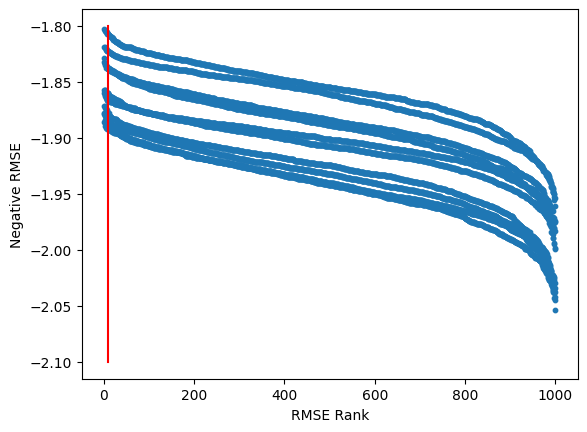

In [88]:
import matplotlib.pyplot as plt
import numpy as np
rank = 'rank_test_neg_root_mean_squared_error'
plt.scatter(x = results.loc[results[rank]<=1000][rank], y = results.loc[results[rank]<=1000]['mean_test_neg_root_mean_squared_error'], s = 10)
plt.xlabel("RMSE Rank")
plt.ylabel("Negative RMSE")
plt.plot([10 for _ in np.arange(-2.1, -1.79, 0.1)], np.arange(-2.1, -1.79, 0.1), c = 'red')
plt.show()